# Scenario

You have trained and optimized YOLO models using the Ultralytics framework and now want to deploy them for high-speed inference. You are considering multiple deployment options, including base PyTorch, TensorRT runtime between different model ssizes

Models were trained on a dataset of custom images on fruit ninja mobile game with 2 classes: 'Bomb' and 'fruit'

Time to process one image (Preprocessing, Inference, Postprocessing) and MAP50 are primary metrics for evaluation. 

`VAL_DATA/` contains validation images for testing. 

NOTE: ALL TESTS ARE DONE ON THE SAME HARDWARE SETUP TO ENSURE FAIR COMPARISON.

## CASES
ALL CASES ARE DONE ON ALL MODELS (PYTORCH, TENSRT FP16, TENSRT INT8)
- DEFAULT : Base model inference with default parameters
- CASE 1 : Stream mode enabled
- CASE 2 : Reduced image size (imgsz=320) [ONLY FOR PYTORCH MODELS]

In [10]:
!nvidia-smi

Tue Jan  6 16:35:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.80                 Driver Version: 581.80         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080      WDDM  |   00000000:01:00.0 Off |                  N/A |
|  0%   28C    P8              7W /  320W |     486MiB /  10240MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3080


# Initialization

In [ ]:
from ultralytics import YOLO
from collections import deque, Counter
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [77]:
# Pre loaded model
model_11n = YOLO('MODELS/Tuned_11n.pt')
model_11s = YOLO('MODELS/Tuned_11s.pt')

model_11n.to('cuda')
model_11s.to('cuda')
print("")

One of the fastest ways to run YOLO models is to convert them to TensorRT format. Below are the steps to export and ultralytics YOLO models to TensorRT format.

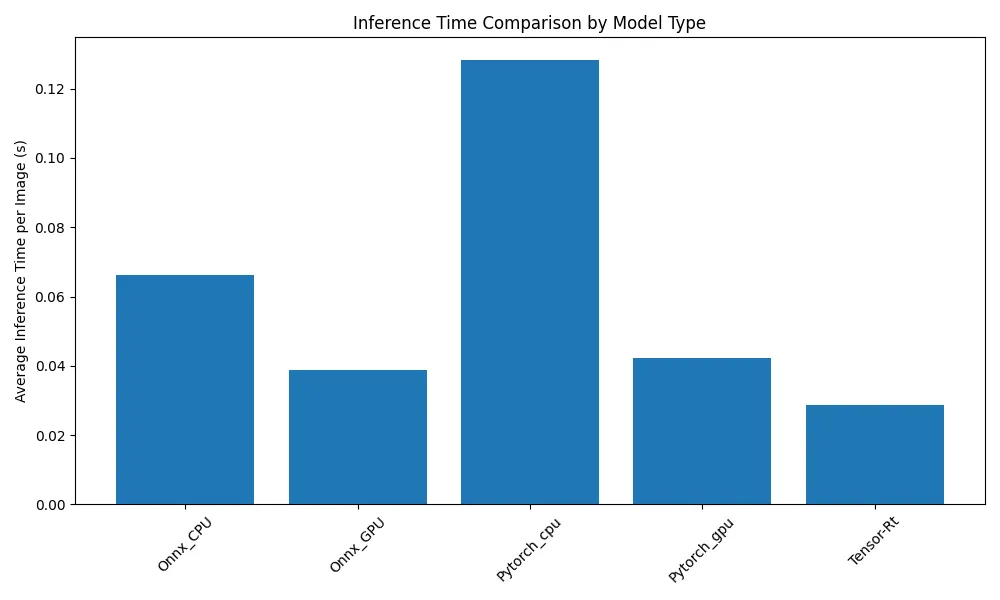

source: https://medium.com/@sundarbalamurugan/comparision-between-tensorrt-pytorch-onnx-runtime-2842bd208d73

In [80]:
# # # Turn all of the models into Tensor-RT engines
# # INT 8 conversion
# model_11n.export(format='engine', int8=True)
# model_11s.export(format='engine', int8=True)

# os.rename("MODELS/Tuned_11n.engine", "MODELS/TUNED_11n_int8.engine")
# os.rename("MODELS/Tuned_11s.engine", "MODELS/TUNED_11s_int8.engine")

# # FP16 conversion
# model_11n.export(format='engine', half=True)
# model_11s.export(format='engine', half=True)

# os.rename("MODELS/Tuned_11n.engine", "MODELS/TUNED_11n_fp16.engine")
# os.rename("MODELS/Tuned_11s.engine", "MODELS/TUNED_11s_fp16.engine")

In [81]:
model_11n_tensorrt_fp16 = YOLO("MODELS/TUNED_11n_fp16.engine", task='detect')
model_11s_tensorrt_fp16 = YOLO("MODELS/TUNED_11s_fp16.engine", task='detect')

model_11n_tensorrt_int8 = YOLO("MODELS/TUNED_11n_int8.engine", task='detect')
model_11s_tensorrt_int8 = YOLO("MODELS/TUNED_11s_int8.engine", task='detect')

# Utils

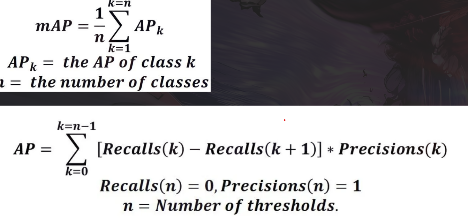

In [268]:
def evaluate_model(model, stream=False, verbose=False, int8=False, half=False, imgsz=640):
    '''
    Evaluate the YOLO model on the validation dataset and compute average inference time, mAP@50, and F1 Score.

    parameters
    ------------
    - model: YOLO
        The YOLO model to be evaluated
    - stream: bool, optional
        Whether to use streaming inference (default is False)
    - verbose: bool, optional
        Whether to print detailed logs (default is False)
    - int8: bool, optional
        Whether to use INT8 precision (default is False)
    - half: bool, optional
        Whether to use FP16 precision (default is False)
    - imgsz: int, optional
        Image size for inference (default is 640)
    ------------
    Returns
    ------------
    - Average_time: str
        Average time to process an image in milliseconds
    - MAP50: float
        Mean Average Precision at IoU 0.5 on the validation dataset
    - F1 Score: float
        F1 Score of the model on the validation dataset (Macro averaged)
    ------------
    '''
    VAL_IMAGES = 'VAL_DATA/images'
    VAL_LABELS = 'VAL_DATA/labels'
    N_IMAGES = len(os.listdir(VAL_IMAGES))

    # Dictionary to map actual labels
    actual_label = {0 : 'fruits', 
                    1 : 'bomb'}
    
    # Initialize metrics of each class
    metrics_class = {
        'fruits' : { 'TP' : 0, 'FP' : 0, 'FN' : 0},
        'bomb' : { 'TP' : 0, 'FP' : 0, 'FN' : 0},
        'background': {'TP': 0, 'FP': 0, 'FN': 0} 
        }

    time_que = list()

    for image in os.listdir(VAL_IMAGES):
        img_path = os.path.join(VAL_IMAGES, image)
        label_path = os.path.join(VAL_LABELS, image.replace('.jpg', '.txt'))

        results = model(source=img_path, conf=0.5, verbose=verbose, iou=0.5,
                        stream=stream, int8=int8, half=half, imgsz=imgsz)

        if stream:
            unpacked = [[i.boxes, i.speed] for i in results] # stream returns a diff structure
            pred_labels = unpacked[0][0].cls.cpu().numpy() if unpacked is not None else []
            time_que.append(unpacked[0][1])

        else:
            preds = results[0].boxes
            pred_labels = preds.cls.cpu().numpy() if preds is not None else []
            time_que.append(results[0].speed)

        pred_labels = [int(x) for x in pred_labels]

        # Get actual labels
        with open(label_path, 'r') as f:
            true_labels = [int(line.strip().split()[0]) for line in f.readlines()]
        
        # This doesn't use bounding box info, only class labels for counting-based confusion matrix
        # Count occurences of each class in true and predicted labels
        true_counts = Counter(true_labels)
        pred_counts = Counter(pred_labels)

        for cls_id, cls_name in actual_label.items():
            n_true = true_counts[cls_id]
            n_pred = pred_counts[cls_id]

            # TP is the overlap (minimum count)
            tp = min(n_true, n_pred)
            # FP is the extra predictions
            fp = max(0, n_pred - n_true)
            # FN is the missed ground truths
            fn = max(0, n_true - n_pred)

            metrics_class[cls_name]['TP'] += tp
            metrics_class[cls_name]['FP'] += fp
            metrics_class[cls_name]['FN'] += fn
            
    # Handle background class
    metrics_class['background']['FP'] = metrics_class['fruits']['FN'] + metrics_class['bomb']['FN'] # Object was present but no box predicted
    metrics_class['background']['FN'] = metrics_class['fruits']['FP'] + metrics_class['bomb']['FP'] # Predicted an object, but it was false


    avg_time = (sum([sum(i.values()) for i in time_que]) / N_IMAGES)

    total_F1 = 0
    total_AP = 0
    
    for cls in ['fruits', 'bomb']:
        TP = metrics_class[cls]['TP']
        FP = metrics_class[cls]['FP']
        FN = metrics_class[cls]['FN']
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0

        # AP = [recall - recall_prev] * precision
        AP = precision * recall  # Simplified AP calculation, assuming single threshold

        total_AP += AP
        F1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        total_F1 += F1
    
    # Average over classes
    mAP50 = total_AP / 2
    F1_score = total_F1 / 2 

    # Confusion matrix
    classes = ['fruits', 'bomb', 'background']
    df_cm = pd.DataFrame({
            'fruits':     [metrics_class['fruits']['TP'], 0, metrics_class['fruits']['FN']],
            'bomb':       [0, metrics_class['bomb']['TP'], metrics_class['bomb']['FN']],
            'background': [metrics_class['fruits']['FP'], metrics_class['bomb']['FP'], 0]
        }
        , index=classes, columns=classes).T

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

    df = pd.DataFrame({
        'Average Inference Time (ms)' : avg_time,
        'mAP@50' : mAP50,
        'F1 Score' : F1_score
    }, index=["values"]).T
    display(df)

    return avg_time, mAP50, F1_score, metrics_class, time_que

# Results

## 11N

### Pytorch

#### DEFAULT PARAMS

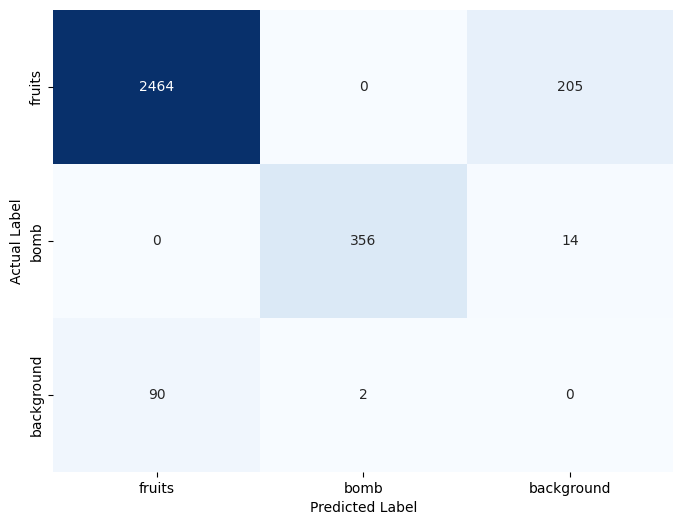

,values
Average Inference Time (ms),15.635193
mAP@50,0.923723
F1 Score,0.960771


In [270]:
yolo11n_pytorch_DEFAULT = evaluate_model(model_11n, stream=False, verbose=False, int8=False, half=False, imgsz=640)

#### CASE 1: Stream mode enabled

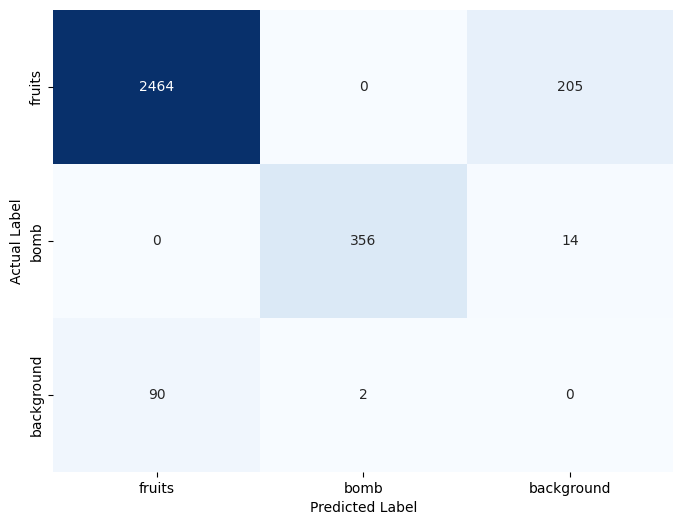

,values
Average Inference Time (ms),15.891795
mAP@50,0.923723
F1 Score,0.960771


In [271]:
yolo11n_pytorch_CASE1 = evaluate_model(model_11n, stream=True, verbose=False, int8=False, half=False, imgsz=640)

#### CASE 2: Reduced image size

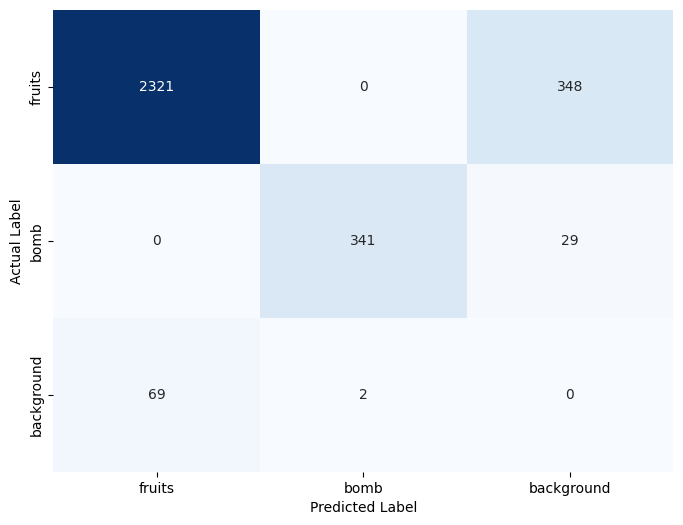

,values
Average Inference Time (ms),14.897658
mAP@50,0.880378
F1 Score,0.937047


In [272]:
yolo11n_pytorch_CASE2 = evaluate_model(model_11n, stream=False, verbose=False, int8=False, half=False, imgsz=320)

### TensorRT FP16

#### DEFAULT PARAMS

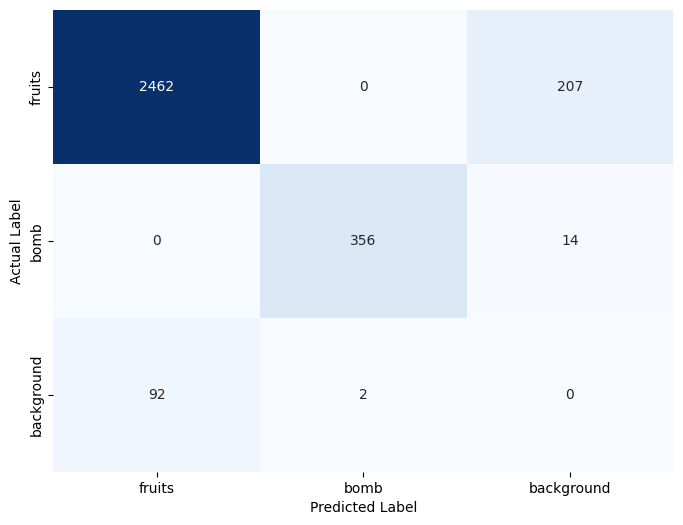

,values
Average Inference Time (ms),6.216140
mAP@50,0.923001
F1 Score,0.960388


In [273]:
yolo11n_TensorRTFP16_DEFAULT = evaluate_model(model_11n_tensorrt_fp16, stream=False, verbose=False, int8=False, half=True, imgsz=640)

#### CASE 1: Stream mode enabled

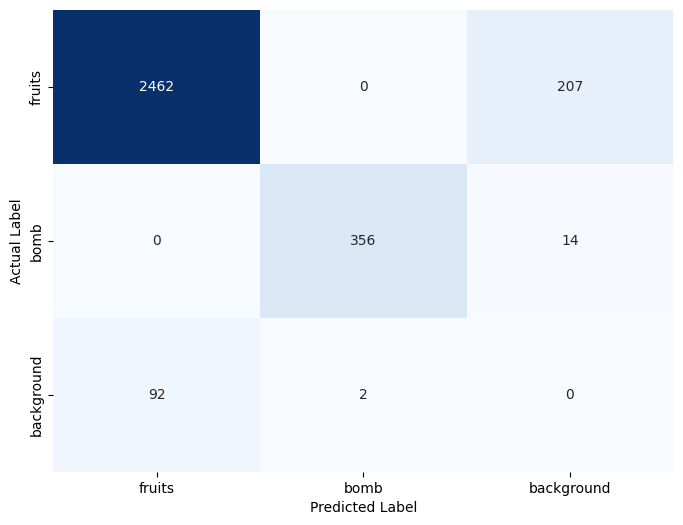

,values
Average Inference Time (ms),5.748430
mAP@50,0.923001
F1 Score,0.960388


In [274]:
yolo11n_TensorRTFP16_CASE1 = evaluate_model(model_11n_tensorrt_fp16, stream=True, verbose=False, int8=False, half=True, imgsz=640)

### TensorRT INT8

#### DEFAULT PARAMS

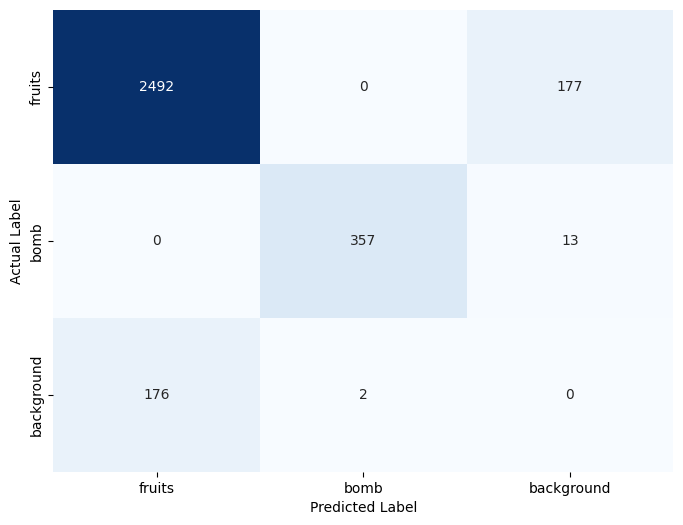

,values
Average Inference Time (ms),6.147326
mAP@50,0.915790
F1 Score,0.956641


In [275]:
yolo11n_TensorRTINT8_DEFAULT = evaluate_model(model_11n_tensorrt_int8, stream=False, verbose=False, int8=True, half=False, imgsz=640)

#### CASE 1: Stream mode enabled

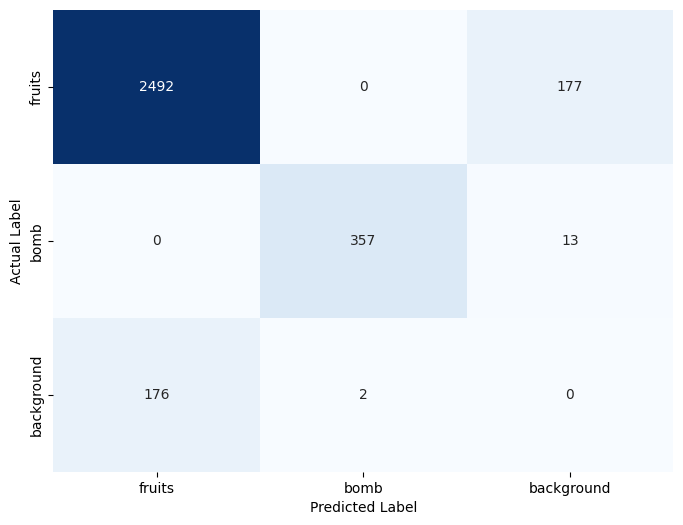

,values
Average Inference Time (ms),5.939651
mAP@50,0.915790
F1 Score,0.956641


In [276]:
yolo11n_TensorRTINT8_CASE1 = evaluate_model(model_11n_tensorrt_int8, stream=True, verbose=False, int8=True, half=False, imgsz=640)

## 11S

### Pytorch

#### DEFAULT PARAMS

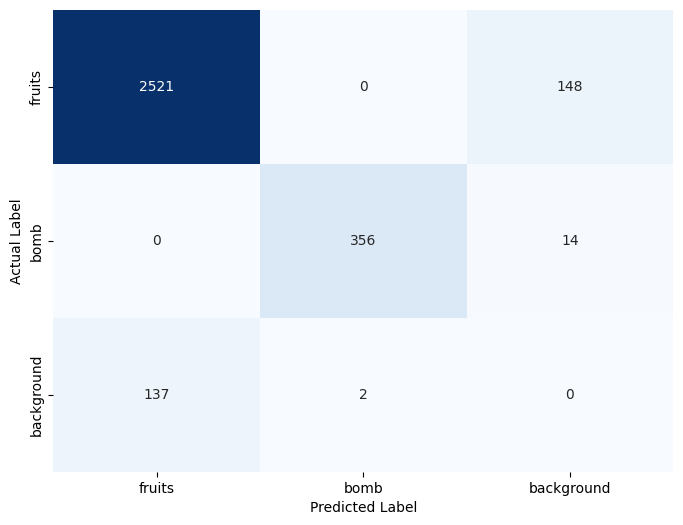

,values
Average Inference Time (ms),15.939015
mAP@50,0.926326
F1 Score,0.962260


In [277]:
yolo11s_pytorch_DEFAULT = evaluate_model(model_11s, stream=False, verbose=False, int8=False, half=False, imgsz=640)

#### CASE 1: Stream mode enabled

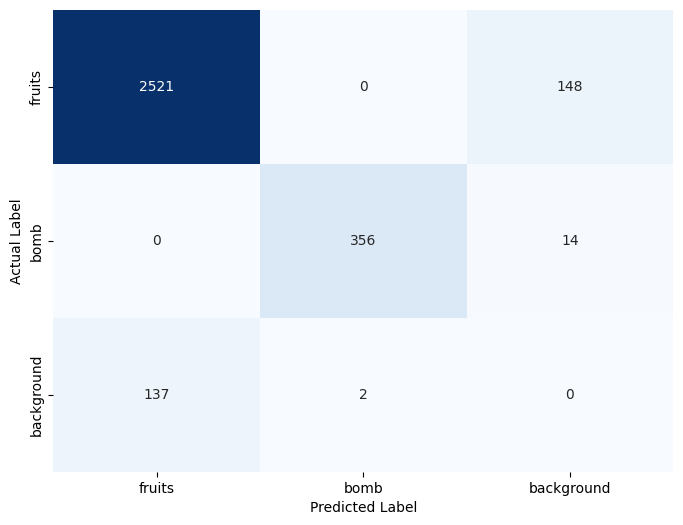

,values
Average Inference Time (ms),15.207751
mAP@50,0.926326
F1 Score,0.962260


In [278]:
yolo11s_pytorch_CASE1 = evaluate_model(model_11s, stream=True, verbose=False, int8=False, half=False, imgsz=640)

#### CASE 2: Reduced image size

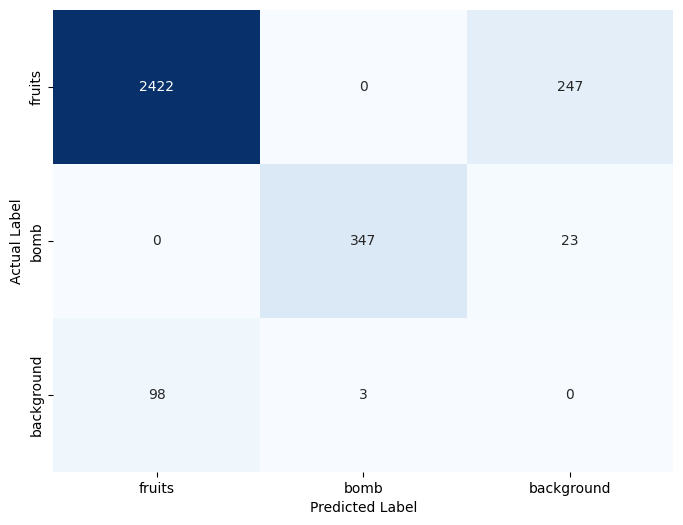

,values
Average Inference Time (ms),14.968512
mAP@50,0.900983
F1 Score,0.948701


In [279]:
yolo11s_pytorch_CASE2 = evaluate_model(model_11s, stream=False, verbose=False, int8=False, half=False, imgsz=320)

### TensorRT FP16

#### DEFAULT PARAMS

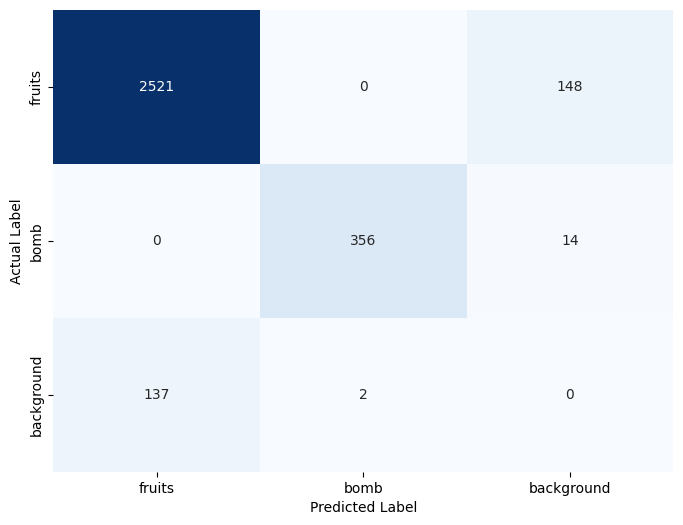

,values
Average Inference Time (ms),5.922910
mAP@50,0.926326
F1 Score,0.962260


In [280]:
yolo11s_TensorRTFP16_DEFAULT = evaluate_model(model_11s_tensorrt_fp16, stream=False, verbose=False, int8=False, half=True, imgsz=640)

#### CASE 1: Stream mode enabled

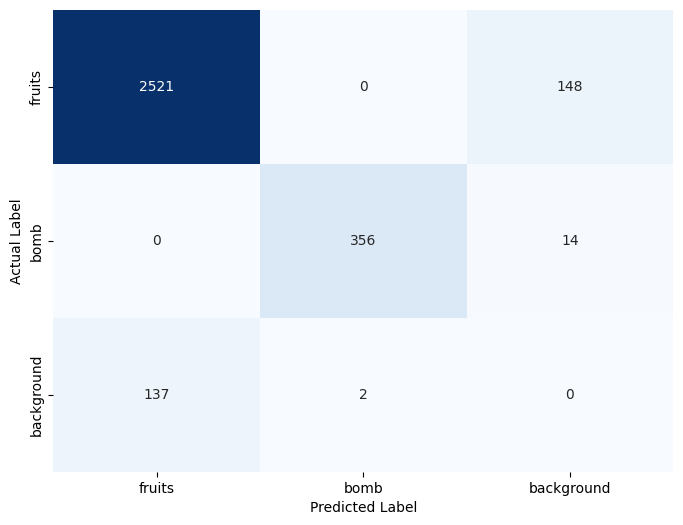

,values
Average Inference Time (ms),6.189661
mAP@50,0.926326
F1 Score,0.962260


In [281]:
yolo11s_TensorRTFP16_CASE1 = evaluate_model(model_11s_tensorrt_fp16, stream=True, verbose=False, int8=False, half=True, imgsz=640)

### TensorRT INT8

#### DEFAULT PARAMS

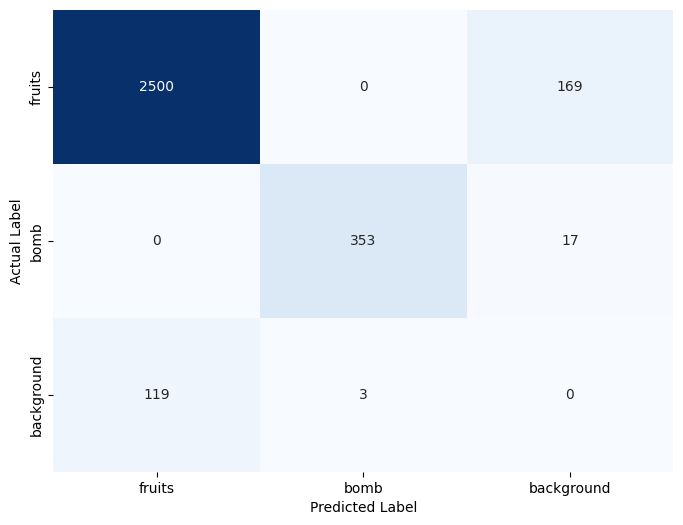

,values
Average Inference Time (ms),6.874182
mAP@50,0.920067
F1 Score,0.958994


In [282]:
yolo11s_TensorRTINT8_DEFAULT = evaluate_model(model_11s_tensorrt_int8, stream=False, verbose=False, int8=True, half=False, imgsz=640)

#### CASE 1: Stream mode enabled

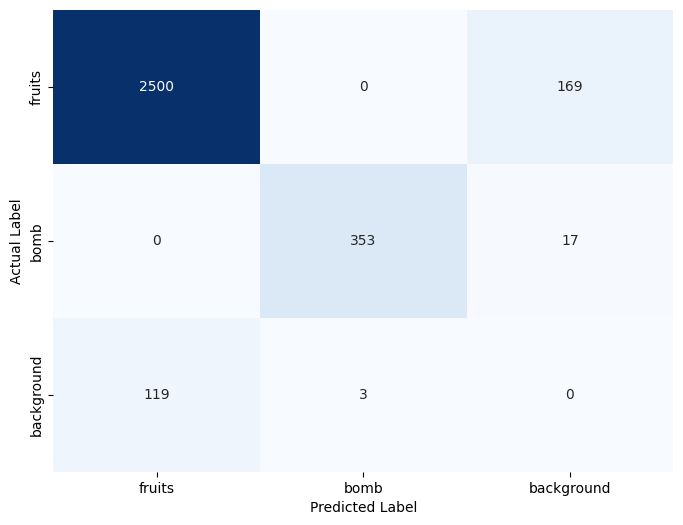

,values
Average Inference Time (ms),6.686281
mAP@50,0.920067
F1 Score,0.958994


In [283]:
yolo11s_TensorRTINT8_CASE1 = evaluate_model(model_11s_tensorrt_int8, stream=True, verbose=False, int8=True, half=False, imgsz=640)

# Summary of Results

In [284]:
summary_df = pd.DataFrame({
    'Model': [ 
        'YOLO11N',
        'YOLO11N',
        'YOLO11N',
        'YOLO11N',
        'YOLO11N',
        'YOLO11N',
        'YOLO11N',
        'YOLO11S',
        'YOLO11S',
        'YOLO11S',
        'YOLO11S',
        'YOLO11S',
        'YOLO11S',
        'YOLO11S'
    ],
    'Framework': [
        'PyTorch',
        'PyTorch',
        'PyTorch',
        'TensorRT FP16',
        'TensorRT FP16',
        'TensorRT INT8',
        'TensorRT INT8',
        'PyTorch',
        'PyTorch',
        'PyTorch',
        'TensorRT FP16',
        'TensorRT FP16',
        'TensorRT INT8',
        'TensorRT INT8'
    ],
    'Configuration': [
        'DEFAULT',
        'CASE 1: Stream mode enabled',
        'CASE 2: Reduced image size',
        'DEFAULT',
        'CASE 1: Stream mode enabled',
        'DEFAULT',
        'CASE 1: Stream mode enabled',
        'DEFAULT',
        'CASE 1: Stream mode enabled',
        'CASE 2: Reduced image size',
        'DEFAULT',
        'CASE 1: Stream mode enabled',
        'DEFAULT',
        'CASE 1: Stream mode enabled'
    ],

    'Average Inference Time (ms)': [
        yolo11n_pytorch_DEFAULT[0],
        yolo11n_pytorch_CASE1[0],
        yolo11n_pytorch_CASE2[0],
        yolo11n_TensorRTFP16_DEFAULT[0],
        yolo11n_TensorRTFP16_CASE1[0],
        yolo11n_TensorRTINT8_DEFAULT[0],
        yolo11n_TensorRTINT8_CASE1[0],
        yolo11s_pytorch_DEFAULT[0],
        yolo11s_pytorch_CASE1[0],
        yolo11s_pytorch_CASE2[0],
        yolo11s_TensorRTFP16_DEFAULT[0],
        yolo11s_TensorRTFP16_CASE1[0],
        yolo11s_TensorRTINT8_DEFAULT[0],
        yolo11s_TensorRTINT8_CASE1[0]
    ],
    'mAP@50': [
        yolo11n_pytorch_DEFAULT[1],
        yolo11n_pytorch_CASE1[1],
        yolo11n_pytorch_CASE2[1],
        yolo11n_TensorRTFP16_DEFAULT[1],
        yolo11n_TensorRTFP16_CASE1[1],
        yolo11n_TensorRTINT8_DEFAULT[1],
        yolo11n_TensorRTINT8_CASE1[1],
        yolo11s_pytorch_DEFAULT[1],
        yolo11s_pytorch_CASE1[1],
        yolo11s_pytorch_CASE2[1],
        yolo11s_TensorRTFP16_DEFAULT[1],
        yolo11s_TensorRTFP16_CASE1[1],
        yolo11s_TensorRTINT8_DEFAULT[1],
        yolo11s_TensorRTINT8_CASE1[1]
    ],
    'F1 Score': [
        yolo11n_pytorch_DEFAULT[2],
        yolo11n_pytorch_CASE1[2],
        yolo11n_pytorch_CASE2[2],
        yolo11n_TensorRTFP16_DEFAULT[2],
        yolo11n_TensorRTFP16_CASE1[2],
        yolo11n_TensorRTINT8_DEFAULT[2],
        yolo11n_TensorRTINT8_CASE1[2],
        
        yolo11s_pytorch_DEFAULT[2],
        yolo11s_pytorch_CASE1[2],
        yolo11s_pytorch_CASE2[2],
        yolo11s_TensorRTFP16_DEFAULT[2],
        yolo11s_TensorRTFP16_CASE1[2],
        yolo11s_TensorRTINT8_DEFAULT[2],
        yolo11s_TensorRTINT8_CASE1[2]
    ]
})

summary_df = summary_df.sort_values(by=['Average Inference Time (ms)'], ascending=True).reset_index(drop=True)
display(summary_df)

,Model,Framework,Configuration,Average Inference Time (ms),mAP@50,F1 Score
0,YOLO11N,TensorRT FP16,CASE 1: Stream mode enabled,5.748430,0.923001,0.960388
1,YOLO11S,TensorRT FP16,DEFAULT,5.922910,0.926326,0.962260
2,YOLO11N,TensorRT INT8,CASE 1: Stream mode enabled,5.939651,0.915790,0.956641
3,YOLO11N,TensorRT INT8,DEFAULT,6.147326,0.915790,0.956641
4,YOLO11S,TensorRT FP16,CASE 1: Stream mode enabled,6.189661,0.926326,0.962260
5,YOLO11N,TensorRT FP16,DEFAULT,6.216140,0.923001,0.960388
6,YOLO11S,TensorRT INT8,CASE 1: Stream mode enabled,6.686281,0.920067,0.958994
7,YOLO11S,TensorRT INT8,DEFAULT,6.874182,0.920067,0.958994
8,YOLO11N,PyTorch,CASE 2: Reduced image size,14.897658,0.880378,0.937047
9,YOLO11S,PyTorch,CASE 2: Reduced image size,14.968512,0.900983,0.948701
